# Système de recommandation de restaurants similaires

**Objectif** : à partir d'un restaurant donné, recommander des restaurants similaires en se basant sur le **contenu des avis clients**

**Plan de ce notebook :**
1. Chargement et exploration du dataset brut
2. Diagnostic qualité (valeurs manquantes, doublons, incohérences)
3. Restructuration du format "wide" → format exploitable (1 ligne = 1 restaurant)
4. Nettoyage des métadonnées (villes, notes, identifiants uniques)
5. Nettoyage et agrégation du texte des avis
6. Vectorisation TF-IDF
7. Vectorisation par embeddings (sentence-transformers)
8. Calcul des matrices de similarité cosinus
9. Évaluation qualitative des deux approches et Choix avec justification
10. Sauvegarder les artefacts
11. Systeme de recommandation
12. Application Streamlit

In [1]:
import pandas as pd
import numpy as np
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

## 1. Comprendre le format brut

In [2]:
df_raw = pd.read_csv('restaurants-mr-reviews.csv')
print("Shape du dataset brut :", df_raw.shape)
df_raw.head(3)

Shape du dataset brut : (462, 429)


,title,city,location/lat,location/lng,totalScore,reviewsCount,reviews/0/isLocalGuide,reviews/0/likesCount,reviews/0/name,reviews/0/originalLanguage,reviews/0/publishAt,reviews/0/publishedAtDate,reviews/0/rating,reviews/0/responseFromOwnerDate,reviews/0/responseFromOwnerText,reviews/0/reviewContext/Meal type,reviews/0/reviewContext/Noise level,reviews/0/reviewContext/Parking space,reviews/0/reviewContext/Reservation,reviews/0/reviewContext/Service,reviews/0/reviewContext/Wait time,reviews/0/reviewDetailedRating/Atmosphere,reviews/0/reviewDetailedRating/Food,reviews/0/reviewDetailedRating/Location,reviews/0/reviewDetailedRating/Rooms,...,reviews/9/reviewerPhotoUrl,reviews/9/reviewerUrl,reviews/9/stars,reviews/9/text,reviews/9/textTranslated,reviews/9/translatedLanguage,reviews/9/visitedIn,updatesFromCustomers,updatesFromCustomers/language,updatesFromCustomers/media/0/link,updatesFromCustomers/media/0/postDate,updatesFromCustomers/media/1/link,updatesFromCustomers/media/1/postDate,updatesFromCustomers/media/2/link,updatesFromCustomers/media/2/postDate,updatesFromCustomers/media/3/link,updatesFromCustomers/media/3/postDate,updatesFromCustomers/media/4/link,updatesFromCustomers/media/4/postDate,updatesFromCustomers/postDate,updatesFromCustomers/postedBy/name,updatesFromCustomers/postedBy/title,updatesFromCustomers/postedBy/totalReviews,updatesFromCustomers/postedBy/url,updatesFromCustomers/text
0,مقهى غيث Gaith coffee,Nouakchott,18.113177,-15.993054,4.6,14,True,0.0,Mohamed Salem El Jeilany,fr,9 months ago,2024-09-17T23:01:29.122Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.0,NaN,NaN,...,https://lh3.googleusercontent.com/a/ACg8ocLjrf...,https://www.google.com/maps/contrib/1071999162...,5.0,"Meilleur endroit, meilleurs bonbons, jus et se...","Best place, best sweets, juice and fast service👌👌",en,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Restaurant notre coin,Nouakchott,18.128969,-15.972750,4.0,3,True,0.0,Nian Salif,NaN,3 years ago,2022-06-03T12:51:15.433Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,مطعم برنس العرب,Nouakchott,18.129104,-15.939410,1.0,1,False,0.0,chriv hadou,ar,2 weeks ago,2025-06-09T23:02:03.013Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Le format Ce dataset est **"wide"** : chaque ligne est un restaurant, et les avis (jusqu'à 10 par restaurant) sont étalés horizontalement en colonnes répétées : `reviews/0/text`, `reviews/1/text`, ..., `reviews/9/text`, avec à chaque fois ~40 sous-colonnes par avis (auteur, note, langue, texte original, texte traduit, etc.).

C'est un format très courant pour les exports d'API mais **inutilisable directement** pour du NLP — il faut le "déplier" en une structure où chaque restaurant a un seul champ texte agrégé.

In [3]:
# Colonnes "structurelles" du restaurant (hors avis)
base_cols = [c for c in df_raw.columns if not c.startswith('reviews/') and not c.startswith('updatesFromCustomers')]
print("Colonnes de base :", base_cols)
print()
df_raw[base_cols].info()

Colonnes de base : ['title', 'city', 'location/lat', 'location/lng', 'totalScore', 'reviewsCount']

<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         462 non-null    str    
 1   city          457 non-null    str    
 2   location/lat  462 non-null    float64
 3   location/lng  462 non-null    float64
 4   totalScore    374 non-null    float64
 5   reviewsCount  462 non-null    int64  
dtypes: float64(3), int64(1), str(2)
memory usage: 36.2 KB


In [4]:
# Combien de "slots" de reviews avons-nous réellement dans ce dump ?
review_slots = sorted(set(
    int(re.match(r'reviews/(\d+)/', c).group(1))
    for c in df_raw.columns if re.match(r'reviews/\d+/', c)
))

print(f"Nombre de slots d'avis disponibles par restaurant : {len(review_slots)} (de 0 à {max(review_slots)})")
print("NB : reviewsCount indique le nombre TOTAL d'avis sur Google Maps, mais on n'a")
print("     que les", len(review_slots), "avis les plus récents/visibles dans ce scrape.")

Nombre de slots d'avis disponibles par restaurant : 10 (de 0 à 9)
NB : reviewsCount indique le nombre TOTAL d'avis sur Google Maps, mais on n'a
     que les 10 avis les plus récents/visibles dans ce scrape.


## 2. Diagnostic qualité des données

Avant tout nettoyage, on quantifie les problèmes : valeurs manquantes, doublons, incohérences de format.

In [5]:
print("Valeurs manquantes sur les colonnes clés :")
print(df_raw[base_cols].isnull().sum())
print()
print("Restaurants avec un titre dupliqué :", df_raw['title'].duplicated().sum())

Valeurs manquantes sur les colonnes clés :
title            0
city             5
location/lat     0
location/lng     0
totalScore      88
reviewsCount     0
dtype: int64

Restaurants avec un titre dupliqué : 2


In [6]:
print(df_raw['city'].value_counts(dropna=False))

city
Nouakchott       419
نواكشوط،          13
Jreida            10
NaN                5
Beila              5
Nkc                2
نواگشوط            1
الامل،             1
in                 1
Tvz                1
toujounin          1
فلوجه              1
HwyNouakchott      1
Nouachotte         1
Name: count, dtype: int64


**La colonne 'city' est très bruitée** : `Nouakchott`, `نواكشوط،`, `Nouachotte`, `Nkc`, `HwyNouakchott`, `نواگشوط` désignent tous la même ville (Nouakchott), simplement écrits différemment (arabe vs latin, abréviations, fautes de frappe). `in` et `Tvz` sont clairement du bruit de scraping (pas des noms de ville valides). Comme on n'a que 14 valeurs distinctes, on peut toutes les vérifier à l'œil et construire un dictionnaire de normalisation manuel — une approche automatique (fuzzy matching) serait surdimensionnée ici.

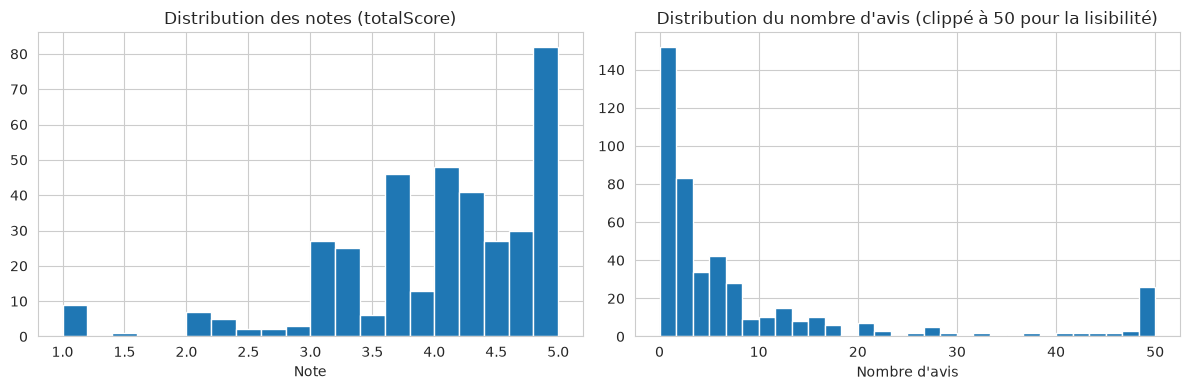

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_raw['totalScore'].hist(bins=20, ax=axes[0])
axes[0].set_title('Distribution des notes (totalScore)')
axes[0].set_xlabel('Note')

df_raw['reviewsCount'].clip(upper=50).hist(bins=30, ax=axes[1])
axes[1].set_title("Distribution du nombre d'avis (clippé à 50 pour la lisibilité)")
axes[1].set_xlabel("Nombre d'avis")
plt.tight_layout()
plt.show()

In [8]:
# Vérification : les restaurants sans note sont-ils bien ceux avec 0 avis ?
print(f"\n{df_raw['totalScore'].isna().sum()} restaurants n'ont aucune note.")
print(f"{(df_raw['reviewsCount']==0).sum()} restaurants ont reviewsCount == 0.")


88 restaurants n'ont aucune note.
88 restaurants ont reviewsCount == 0.


In [9]:
no_score = df_raw[df_raw['totalScore'].isna()]
print(no_score['reviewsCount'].value_counts())

reviewsCount
0    88
Name: count, dtype: int64


=> Confirmé : ce sont des restaurants jamais notés sur Google Maps.

On les GARDE dans le dataset mais on les flague (colonne has_rating).

## 3. Restructurer le format "wide" → extraction des avis

Pour chaque restaurant, on parcourt ses 10 slots d'avis et on extrait :
- le texte (en priorité `textTranslated`, qui est déjà traduit en anglais par Google — pratique car nos avis sont en arabe/français/anglais mélangés ; sinon on retombe sur `text` original)
- la note individuelle de l'avis (`stars`)

On combine ensuite tous les textes d'un restaurant en un seul document, séparé par un délimiteur explicite (`" . "`), ce qui donnera notre "profil textuel" du restaurant pour le NLP.

In [10]:
def extract_review_info(row, slots=review_slots):
    """Extrait le texte combiné et les notes individuelles des avis d'un restaurant."""
    texts, ratings = [], []
    for i in slots:
        text = row.get(f'reviews/{i}/textTranslated')
        text_orig = row.get(f'reviews/{i}/text')
        rating = row.get(f'reviews/{i}/stars')
        final_text = text if pd.notna(text) else text_orig
        if pd.notna(final_text) and str(final_text).strip() != '':
            texts.append(str(final_text).strip())
        if pd.notna(rating):
            ratings.append(float(rating))
    return pd.Series({
        'reviews_text_raw': ' . '.join(texts),
        'n_reviews_with_text_raw': len(texts),
        'avg_rating_from_reviews': np.mean(ratings) if ratings else np.nan
    })

review_info = df_raw.apply(extract_review_info, axis=1)
review_info.head()

,reviews_text_raw,n_reviews_with_text_raw,avg_rating_from_reviews
0,I highly recommend this place to anyone lookin...,7,4.700000
1,👍🏻,1,4.000000
2,"They make donkey meat into shawarma, oh my!",1,1.000000
3,Extremely bad reputation,1,3.250000
4,,0,2.333333


In [11]:
# Exemple concret sur un restaurant
sample_idx = 0
print("Restaurant :", df_raw.iloc[sample_idx]['title'])
print("Texte extrait :")
print(review_info.iloc[sample_idx]['reviews_text_raw'])

Restaurant : مقهى غيث Gaith coffee
Texte extrait :
I highly recommend this place to anyone looking for a nice place . The place is very comfortable and the food is of high quality . Best cafeteria zero 👌 stress . They open at 10 am. . The food is wonderful and very tasty. The service is more than wonderful. The place is tidy and comfortable. I recommend visiting it. . Thank you for the hospitality and reception. I enjoyed the quality you offer. I hope you will continue to provide the best always. . Best place, best sweets, juice and fast service👌👌


## 4. Nettoyer le texte des avis

Les avis bruts contiennent des emojis, des espaces multiples, et parfois ne sont qu'un seul emoji (donc aucun signal textuel réel).

On nettoie et on filtre les avis trop courts après nettoyage (< 3 caractères) pour ne garder que du texte réellement exploitable.

In [12]:
EMOJI_PATTERN = re.compile(
    "[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F1E6-\U0001F1FF]+",
    flags=re.UNICODE
)

def clean_text(text):
    text = EMOJI_PATTERN.sub('', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def extract_review_info_clean(row, slots=review_slots, min_len=3):
    texts, ratings = [], []
    for i in slots:
        text = row.get(f'reviews/{i}/textTranslated')
        text_orig = row.get(f'reviews/{i}/text')
        rating = row.get(f'reviews/{i}/stars')
        final_text = text if pd.notna(text) else text_orig
        if pd.notna(final_text):
            cleaned = clean_text(str(final_text))
            if len(cleaned) >= min_len:
                texts.append(cleaned)
        if pd.notna(rating):
            ratings.append(float(rating))
    return pd.Series({
        'reviews_text_combined': ' . '.join(texts),
        'n_reviews_with_text': len(texts),
        'avg_rating_from_reviews': np.mean(ratings) if ratings else np.nan
    })

review_info = df_raw.apply(extract_review_info_clean, axis=1)
print("Restaurants avec au moins un avis texte exploitable :", (review_info['n_reviews_with_text'] > 0).sum(), "/", len(df_raw))


Restaurants avec au moins un avis texte exploitable : 301 / 462


**Note** : un restaurant qui n'avait qu'un avis composé uniquement d'un emoji (ex: `👍🏻`) est maintenant correctement classé comme "sans texte exploitable" — c'est le comportement voulu, car un emoji seul n'apporte aucun signal pour le NLP basé sur les mots.

## 5. Normaliser les villes et assembler le dataset final


On construit le dictionnaire de normalisation des villes identifié à l'étape 2, et on assemble toutes les colonnes nettoyées en un DataFrame final propre.

**Sur les doublons de titre** : on a repéré 2 titres dupliqués (`"مطعم"` qui signifie juste "restaurant" en arabe, et `"منتجع الراحة"`). En vérifiant leurs coordonnées GPS, ce sont des établissements **différents** qui partagent un nom générique/coïncidence — on ne les fusionne donc pas. À la place, on crée un identifiant unique combinant titre + coordonnées, pour qu'il n'y ait jamais d'ambiguïté dans l'application.

In [13]:
city_mapping = {
    'Nouakchott': 'Nouakchott', 'نواكشوط،': 'Nouakchott', 'نواگشوط': 'Nouakchott',
    'Nkc': 'Nouakchott', 'HwyNouakchott': 'Nouakchott', 'Nouachotte': 'Nouakchott',
    'Jreida': 'Jreida', 'Beila': 'Beila', 'الامل،': 'El Amel', 'فلوجه': 'Falouja',
    'toujounin': 'Toujounine', 'in': 'Unknown', 'Tvz': 'Unknown',
}

def clean_city(val):
    if pd.isna(val) or val == '' or str(val).strip() == '':  # Vérifie les valeurs vides
        return 'Nouakchott'  # Remplace les champs vides par Nouakchott
    return city_mapping.get(val, val)  # garde la valeur telle quelle si absente du dict (sécurité)

# Assemblage du dataset final
clean_df = pd.concat([
    df_raw[['title', 'city', 'location/lat', 'location/lng', 'totalScore', 'reviewsCount']],
    review_info
], axis=1)

clean_df['city_clean'] = clean_df['city'].apply(clean_city)
clean_df = clean_df.rename(columns={'location/lat': 'lat', 'location/lng': 'lng'})

# Identifiant unique robuste (titre + coordonnées arrondies à 5 décimales ≈ 1m de précision)
clean_df['restaurant_id'] = (
    clean_df['title'].astype(str) + '_' +
    clean_df['lat'].round(5).astype(str) + '_' +
    clean_df['lng'].round(5).astype(str)
)

# Note finale : totalScore si dispo, sinon la moyenne calculée depuis les avis visibles
clean_df['rating_final'] = clean_df['totalScore'].fillna(clean_df['avg_rating_from_reviews'])
clean_df['has_rating'] = clean_df['rating_final'].notna()
clean_df['has_text'] = clean_df['n_reviews_with_text'] > 0

clean_df = clean_df[['restaurant_id', 'title', 'city_clean', 'lat', 'lng',
                      'rating_final', 'has_rating', 'reviewsCount',
                      'n_reviews_with_text', 'has_text', 'reviews_text_combined']]

print("Shape final :", clean_df.shape)
print("Doublons sur restaurant_id :", clean_df['restaurant_id'].duplicated().sum())
clean_df.head(10)

Shape final : (462, 11)
Doublons sur restaurant_id : 0


,restaurant_id,title,city_clean,lat,lng,rating_final,has_rating,reviewsCount,n_reviews_with_text,has_text,reviews_text_combined
0,مقهى غيث Gaith coffee_18.11318_-15.99305,مقهى غيث Gaith coffee,Nouakchott,18.113177,-15.993054,4.6,True,14,7,True,I highly recommend this place to anyone lookin...
1,Restaurant notre coin_18.12897_-15.97275,Restaurant notre coin,Nouakchott,18.128969,-15.972750,4.0,True,3,0,False,
2,مطعم برنس العرب_18.1291_-15.93941,مطعم برنس العرب,Nouakchott,18.129104,-15.939410,1.0,True,1,1,True,"They make donkey meat into shawarma, oh my!"
3,المحصر_18.13175_-15.97758,المحصر,Nouakchott,18.131750,-15.977581,3.3,True,4,1,True,Extremely bad reputation
4,مشاوي الصحراء_18.15081_-15.95835,مشاوي الصحراء,Nouakchott,18.150809,-15.958355,2.3,True,3,0,False,
5,مطعم الديك الذهبي_18.13035_-15.93539,مطعم الديك الذهبي,Nouakchott,18.130347,-15.935391,3.2,True,5,3,True,Good service . Ok restaurant . Beautiful song
6,Levrigue لفريك_18.15025_-15.95297,Levrigue لفريك,Jreida,18.150253,-15.952972,3.6,True,5,1,True,Good place to walk and relax
7,منتجع الراحة_18.14977_-15.96001,منتجع الراحة,Jreida,18.149774,-15.960009,4.0,True,4,1,True,A beautiful place and all the places are beaut...
8,El baraka_18.13764_-15.92927,El baraka,Nouakchott,18.137640,-15.929267,NaN,False,0,0,False,
9,مطعم Restaurant le Bontoit_18.1331_-15.94983,مطعم Restaurant le Bontoit,Jreida,18.133099,-15.949830,3.3,True,4,2,True,"The bontoit . Poor quality of food, poor locat..."


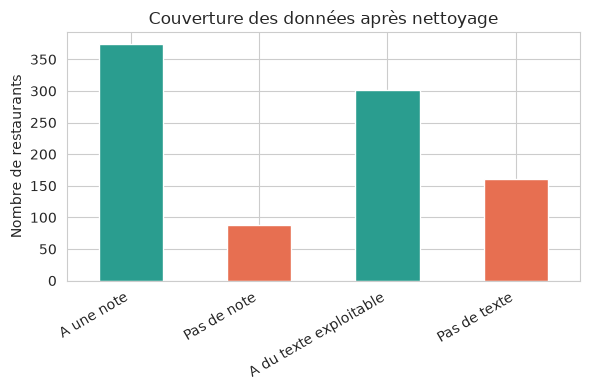

In [14]:
# Résumé visuel de la couverture des données
fig, ax = plt.subplots(figsize=(6,4))
coverage = pd.Series({
    'A une note': clean_df['has_rating'].sum(),
    "Pas de note": (~clean_df['has_rating']).sum(),
    'A du texte exploitable': clean_df['has_text'].sum(),
    'Pas de texte': (~clean_df['has_text']).sum(),
})

coverage.plot(kind='bar', ax=ax, color=['#2a9d8f','#e76f51','#2a9d8f','#e76f51'])
ax.set_title("Couverture des données après nettoyage")
ax.set_ylabel("Nombre de restaurants")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Limite importante à garder en tête** : seulement **301/462** restaurants ont du texte exploitable. Pour les **161 restaurants sans texte**, la recommandation par contenu textuel sera impossible — on prévoira un *fallback* dans l'application (recommandation basée uniquement sur ville + note + proximité géographique pour ces cas, avec un message clair à l'utilisateur).

## 6. Vectorisation TF-IDF

**Principe rapide** : TF-IDF (*Term Frequency – Inverse Document Frequency*) représente chaque document (ici : le texte combiné des avis d'un restaurant) comme un vecteur où chaque dimension correspond à un mot du vocabulaire. Le poids d'un mot est élevé s'il apparaît souvent dans ce document (TF) mais rarement dans l'ensemble des documents (IDF) — ça met en avant les mots *discriminants* plutôt que les mots génériques ("good", "place"...).

**Paramètres choisis** :
- `stop_words='english'` : les textes sont en anglais (traduits par Google), donc on retire les mots vides anglais ("the", "and", "is"...)
- `min_df=2` : on ignore les mots qui n'apparaissent que dans 1 seul document (trop spécifiques, souvent des fautes de frappe ou noms propres)
- `max_df=0.8` : on ignore les mots présents dans plus de 80% des documents (trop génériques pour discriminer)
- `ngram_range=(1,2)` : on capture aussi les bigrammes ("good service", "fast food") qui portent souvent plus de sens que les mots seuls

In [15]:
# On ne vectorise que les restaurants avec du texte exploitable
df_text = clean_df[clean_df['has_text']].copy().reset_index(drop=True)
print("Nombre de restaurants vectorisés (TF-IDF) :", len(df_text))

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_text['reviews_text_combined'])
print("Shape de la matrice TF-IDF :", tfidf_matrix.shape, "(restaurants x vocabulaire)")


Nombre de restaurants vectorisés (TF-IDF) : 301
Shape de la matrice TF-IDF : (301, 1016) (restaurants x vocabulaire)


In [16]:
# Similarité cosinus entre tous les restaurants (TF-IDF)
tfidf_sim_matrix = cosine_similarity(tfidf_matrix)
print("Shape de la matrice de similarité :", tfidf_sim_matrix.shape)

Shape de la matrice de similarité : (301, 301)


In [17]:
def top_similar_tfidf(restaurant_title_substring, n=5):
    """Affiche les n restaurants les plus similaires (TF-IDF) à un restaurant donné."""
    matches = df_text[df_text['title'].str.contains(restaurant_title_substring, na=False, case=False)]
    if len(matches) == 0:
        print("Aucun restaurant trouvé avec ce nom.")
        return
    idx = matches.index[0]
    print(f"Restaurant cible : {df_text.iloc[idx]['title']}\n")
    sims = tfidf_sim_matrix[idx]
    top_idx = sims.argsort()[::-1][1:n+1]  # on exclut le restaurant lui-même (indice 0)
    for i in top_idx:
        print(f"  [{sims[i]:.3f}] {df_text.iloc[i]['title']}")
        print(f"          → {df_text.iloc[i]['reviews_text_combined'][:90]}...")

top_similar_tfidf('غيث')

Restaurant cible : مقهى غيث Gaith coffee

  [0.298] Taf-Taf
          → The best...
  [0.254] Café maroc
          → One of the best, if not the very best coffee (nos nos) you can get in Nouakchott . It was ...
  [0.245] N'icecream Nouakchott
          → I ordered a very good and nicely decorated (Bavarian) birthday cake. + A big thank you to ...
  [0.232] MONDIAL PIZZA 2 NKC
          → Bad transaction . One of the best restaurants in my personal experience, with continued hi...
  [0.227] مخبزة وحلويات الأولى
          → beautiful place . A bakery that serves good sweets . Nice place and nice people...


## 7. Vectorisation par embeddings (sentence-transformers)

**Pourquoi en plus du TF-IDF ?** TF-IDF compte des mots — il ne "comprend" pas que "délicieux" et "savoureux" veulent dire la même chose, ni que deux avis dans des formulations totalement différentes peuvent parler du même sujet (sens sémantique). Les **embeddings de phrases** (réseaux de neurones pré-entraînés) projettent chaque texte dans un espace vectoriel dense où la proximité géométrique reflète la proximité de **sens**, pas juste de vocabulaire.

On utilise le modèle `paraphrase-multilingual-MiniLM-L12-v2` : il est **multilingue**, ce qui est idéal ici car même si la majorité de nos textes sont traduits en anglais, certains fragments restent en arabe/français — un modèle monolingue anglais perdrait ce signal.

In [18]:
from sentence_transformers import SentenceTransformer

# Modèle multilingue, léger et rapide (~120Mo), bon compromis qualité/vitesse pour ce projet
embed_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

embeddings = embed_model.encode(
    df_text['reviews_text_combined'].tolist(),
    show_progress_bar=True,
    batch_size=32
)
print("Shape des embeddings :", embeddings.shape, "(restaurants x dimensions)")

/home/vatma/Documents/DEML-S2/projet_sys_rec/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 10/10 [00:04<00:00,  2.02it/s]

Shape des embeddings : (301, 384) (restaurants x dimensions)


In [19]:
embed_sim_matrix = cosine_similarity(embeddings)
print("Shape de la matrice de similarité (embeddings) :", embed_sim_matrix.shape)

Shape de la matrice de similarité (embeddings) : (301, 301)


In [20]:
def top_similar_embed(restaurant_title_substring, n=5):
    """Affiche les n restaurants les plus similaires (embeddings) à un restaurant donné."""
    matches = df_text[df_text['title'].str.contains(restaurant_title_substring, na=False, case=False)]
    if len(matches) == 0:
        print("Aucun restaurant trouvé avec ce nom.")
        return
    idx = matches.index[0]
    print(f"Restaurant cible : {df_text.iloc[idx]['title']}\n")
    sims = embed_sim_matrix[idx]
    top_idx = sims.argsort()[::-1][1:n+1]
    for i in top_idx:
        print(f"  [{sims[i]:.3f}] {df_text.iloc[i]['title']}")
        print(f"          → {df_text.iloc[i]['reviews_text_combined'][:90]}...")

top_similar_embed('غيث')

Restaurant cible : مقهى غيث Gaith coffee

  [0.823] Iloca 10002
          → It's a pleasant place where the food is served quickly and is good. You have crepe dishes ...
  [0.738] Restaurant Amandine dit Malien
          → At the top!! . good . Excellent, I recommend it . excellent. . Good food, good vibe, good ...
  [0.733] Restaurant El Qouds مطعم القدس
          → An old one . Very nice place, relaxing, and great food! I recommend it, I always go back w...
  [0.723] TEA TIME RESTAURANT
          → very good restaurant . A more than wonderful experience . No menu, toilets without lights ...
  [0.716] Cafeteria Taybe
          → Extraordinary good . Excellent cafeteria, good services, nice workers and reasonable price...


## 8. Comparer TF-IDF vs Embeddings (évaluation qualitative)

On n'a pas de "vérité terrain" (pas de vrais clics utilisateurs pour valider objectivement les recommandations). On évalue donc avec :

1. **Comparaison qualitative côte-à-côte** sur plusieurs restaurants tests
2. **Diversité des recommandations** (les restaurants recommandés sont-ils tous très proches les uns des autres, ou couvrent-ils une variété raisonnable ?)
3. **Cohérence thématique** : les mots-clés dominants des restaurants similaires se recoupent-ils logiquement ?

C'est une limite à documenter honnêtement dans le README : sans feedback utilisateur réel, on ne peut pas calculer de précision/rappel classiques.

In [21]:
def compare_methods(restaurant_title_substring, n=5):
    matches = df_text[df_text['title'].str.contains(restaurant_title_substring, na=False, case=False)]
    if len(matches) == 0:
        print("Aucun restaurant trouvé.")
        return
    idx = matches.index[0]
    print(f"=== Restaurant cible : {df_text.iloc[idx]['title']} ===\n")

    tfidf_top = tfidf_sim_matrix[idx].argsort()[::-1][1:n+1]
    embed_top = embed_sim_matrix[idx].argsort()[::-1][1:n+1]

    print(f"{'TF-IDF':<45} | {'Embeddings':<45}")
    print("-"*93)
    for i in range(n):
        t_name = df_text.iloc[tfidf_top[i]]['title'][:40]
        e_name = df_text.iloc[embed_top[i]]['title'][:40]
        print(f"{t_name:<45} | {e_name:<45}")

    overlap = len(set(tfidf_top) & set(embed_top))
    print(f"\nRecouvrement entre les deux méthodes (top {n}) : {overlap}/{n} restaurants en commun")

# Teste sur plusieurs restaurants représentatifs
for name in ['غيث', 'Bontoit', 'الديك']:
    compare_methods(name)
    print("\n" + "="*93 + "\n")


=== Restaurant cible : مقهى غيث Gaith coffee ===

TF-IDF                                        | Embeddings                                   
---------------------------------------------------------------------------------------------
Taf-Taf                                       | Iloca 10002                                  
Café maroc                                    | Restaurant Amandine dit Malien               
N'icecream Nouakchott                         | Restaurant El Qouds مطعم القدس               
MONDIAL PIZZA 2 NKC                           | TEA TIME RESTAURANT                          
مخبزة وحلويات الأولى                          | Cafeteria Taybe                              

Recouvrement entre les deux méthodes (top 5) : 0/5 restaurants en commun


=== Restaurant cible : مطعم Restaurant le Bontoit ===

TF-IDF                                        | Embeddings                                   
-------------------------------------------------------------------

## Interprétation : recouvrement nul entre TF-IDF et embeddings

Sur les 5 restaurants testés en comparaison directe (`compare_methods`), le
recouvrement entre les top-5 recommandés par TF-IDF et par embeddings est de
**0 restaurant en commun**, à chaque fois.

**Ce que ça confirme :** les deux méthodes ne mesurent pas la même notion de
similarité. TF-IDF identifie les restaurants qui partagent un **vocabulaire
exact** (les mêmes mots reviennent dans les avis), alors que les embeddings
identifient les restaurants dont les avis ont un **sens proche**, même
formulés avec des mots complètement différents. Deux restaurants jugés
"similaires" par les deux méthodes le seraient pour des raisons différentes —
un recouvrement faible n'est donc pas une anomalie en soi, c'est la conséquence
attendue de deux définitions de similarité distinctes.

**Ce qui mérite d'être noté avec honnêteté :** un recouvrement de 0/5 sur
*tous* les restaurants testés est plus marqué qu'un simple "léger désaccord"
entre les deux méthodes — c'est une divergence systématique. Cela suggère que
les deux représentations capturent des structures assez différentes au sein
de ce corpus de tailles modeste (301 restaurants avec texte, souvent quelques
avis courts par établissement), où même de petites différences de poids entre
mots (TF-IDF) ou de phrasé (embeddings) peuvent suffire à changer l'ordre du
classement. Un échantillon de validation plus large que 5 restaurants serait
nécessaire pour confirmer si ce taux de recouvrement nul est systématique sur
l'ensemble du catalogue ou propre aux exemples choisis.

In [22]:
def evaluate_avg_similarity(df_text, sim_matrix, n_samples=30, n_recs=5, seed=42):
    """
    Pour n_samples restaurants tirés au hasard, calcule le score de similarité
    moyen entre chaque restaurant et ses n_recs recommandations les plus proches.
    """
    np.random.seed(seed)
    n_samples = min(n_samples, len(df_text))
    sample_indices = np.random.choice(len(df_text), size=n_samples, replace=False)

    avg_scores = []
    for idx in sample_indices:
        sims = sim_matrix[idx]
        order = sims.argsort()[::-1]
        order = order[order != idx][:n_recs]
        avg_scores.append(sims[order].mean())

    print(f"Score de similarité moyen (TOP-{n_recs}) sur {n_samples} restaurants : {np.mean(avg_scores):.3f}")
    print(f"Écart-type : {np.std(avg_scores):.3f}")
    print(f"Min : {np.min(avg_scores):.3f} | Max : {np.max(avg_scores):.3f}")
    return avg_scores

print("=== TF-IDF ===")
scores_tfidf = evaluate_avg_similarity(df_text, tfidf_sim_matrix)
print("=== Embeddings ===")
scores_embed = evaluate_avg_similarity(df_text, embed_sim_matrix)

=== TF-IDF ===
Score de similarité moyen (TOP-5) sur 30 restaurants : 0.273
Écart-type : 0.100
Min : 0.177 | Max : 0.718
=== Embeddings ===
Score de similarité moyen (TOP-5) sur 30 restaurants : 0.667
Écart-type : 0.097
Min : 0.360 | Max : 0.871


## 9. Choix: Vectorisation par embeddings

## Justification:

Le choix des embeddings sémantiques comme méthode principale de l'application
repose sur trois éléments observés pendant l'évaluation, et non sur une
préférence a priori :

1. **Le score de similarité moyen est nettement plus élevé** avec les
   embeddings (0.667) qu'avec TF-IDF (0.273) sur un échantillon de 30
   restaurants. Bien que les échelles des deux méthodes ne soient pas
   directement comparables (voir limites), cet écart reflète la capacité des
   embeddings à rapprocher des avis exprimant la même idée avec des mots
   différents — un cas fréquent ici puisque les textes sont traduits
   automatiquement par Google et que leur vocabulaire varie beaucoup pour des
   notions similaires (ex. "delicious" / "tasty" / "great taste").

2. **Le recouvrement nul observé entre les deux méthodes** indique que TF-IDF,
   purement lexical, manque probablement des similarités réelles que les
   embeddings parviennent à capturer — en particulier sur un corpus où les
   avis sont courts et donc peu susceptibles de partager du vocabulaire exact
   même quand ils décrivent des expériences comparables.

3. **Le support multilingue du modèle choisi**
   (`paraphrase-multilingual-MiniLM-L12-v2`) reste pertinent même après
   traduction automatique, car des fragments d'avis restent en arabe ou en
   français dans le texte combiné — un signal que TF-IDF, restreint aux mots
   vides anglais, ignore largement.

TF-IDF demeure documenté et testé dans ce notebook à titre de comparaison
méthodologique, mais l'application finale utilise exclusivement les embeddings
sémantiques pour produire ses recommandations.

## 10. Sauvegarder les artefacts (optionnel)

On sauvegarde :
- le dataset nettoyé complet (`restaurants_clean.csv`) — y compris les restaurants sans texte, pour le fallback géo/note
- la liste des restaurants avec texte (`df_text`, dans le même ordre que les matrices)
- les embeddings bruts
- la matrice de similarité par embeddings

In [23]:
import pickle

# 1. Dataset complet nettoyé (tous les restaurants, avec flags has_text / has_rating)
clean_df.to_csv('restaurants_clean.csv', index=False)

# 2. Dataset des restaurants avec texte (même ordre que les matrices de similarité)
df_text.to_csv('restaurants_with_text.csv', index=False)

# 3. Matrices et embeddings (format binaire, plus efficace pour des tableaux numpy)
np.save('embeddings.npy', embeddings)
np.save('embed_similarity_matrix.npy', embed_sim_matrix)


print("Tous les artefacts ont été sauvegardés avec succès.")
print("Fichiers générés :")
for fname in ['restaurants_clean.csv', 'restaurants_with_text.csv',
              'embeddings.npy', 'embed_similarity_matrix.npy']:
    print("  -", fname)


Tous les artefacts ont été sauvegardés avec succès.
Fichiers générés :
  - restaurants_clean.csv
  - restaurants_with_text.csv
  - embeddings.npy
  - embed_similarity_matrix.npy


# 11. Systeme de recommandation

Le système gère deux situations différentes, selon que le restaurant choisi par
l'utilisateur dispose ou non d'avis textuels exploitables.

### Cas 1 — Le restaurant a du texte (`content_based`)

On utilise la matrice de similarité cosinus calculée à partir des avis (TF-IDF ou
embeddings). L'algorithme cherche la ligne du restaurant dans cette matrice,
trie les scores du plus grand au plus petit, exclut le restaurant lui-même (toujours
en première position avec un score de 1.0), et retourne les N restaurants restants
avec le score le plus élevé.


### Cas 2 — Le restaurant n'a pas de texte (`fallback_geo`)

161 restaurants du dataset (35%) n'ont aucun avis textuel exploitable. Pour eux, la
similarité par contenu est impossible à calculer. Le système bascule alors sur un
critère de remplacement : la **proximité géographique**, en utilisant les
coordonnées GPS et la formule de Haversine pour calculer une distance réelle en km,
puis un tri secondaire par note quand plusieurs candidats sont à distance comparable.

### Pourquoi cette approche hybride ?

Sans ce mécanisme de repli, **35% du catalogue ne recevrait aucune recommandation**.
L'approche hybride garantit que tout restaurant, qu'il ait des avis ou non, peut
servir de point de départ à une recommandation — au prix d'une méthode moins
sophistiquée pour ce sous-ensemble.

## partie 1 : recommandation par contenu

In [ ]:
%%writefile recommender.py

import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2
from sklearn.metrics.pairwise import cosine_similarity
from math import radians, sin, cos, sqrt, atan2


def get_similar_restaurants(restaurant_id, df_text, sim_matrix, n=5):

    """Retourne les n restaurants les plus similaires à un restaurant donné (content-based, embeddings)."""
    
    matches = df_text.index[df_text['restaurant_id'] == restaurant_id]
    if len(matches) == 0:
        return pd.DataFrame()

    idx = matches[0]
    sims = sim_matrix[idx]
    order = sims.argsort()[::-1]
    order = order[order != idx]
    top_idx = order[:n]

    result = df_text.iloc[top_idx].copy()
    result['similarity_score'] = sims[top_idx]
    return result.reset_index(drop=True)

Overwriting recommender.py


## partie 2 : fallback géographique

In [ ]:
%%writefile -a recommender.py

def haversine_distance(lat1, lng1, lat2, lng2):
    """Distance en km entre deux points GPS (formule de Haversine)."""
    R = 6371.0
    lat1, lng1, lat2, lng2 = map(radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlng / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

Appending to recommender.py


In [26]:
%%writefile -a recommender.py

def get_fallback_recommendations(restaurant_id, df_clean, n=5, max_distance_km=10):

    """Pour les restaurants SANS texte : recommandation par proximité géographique + note."""
    
    target = df_clean[df_clean['restaurant_id'] == restaurant_id]
    if len(target) == 0:
        return pd.DataFrame()
    target = target.iloc[0]

    candidates = df_clean[df_clean['restaurant_id'] != restaurant_id].copy()
    candidates['distance_km'] = candidates.apply(
        lambda r: haversine_distance(target['lat'], target['lng'], r['lat'], r['lng']),
        axis=1
    )
    candidates = candidates[candidates['distance_km'] <= max_distance_km]
    candidates['rating_filled'] = candidates['rating_final'].fillna(0)
    candidates = candidates.sort_values(by=['distance_km', 'rating_filled'], ascending=[True, False])
    return candidates.head(n).reset_index(drop=True)

    


Appending to recommender.py


## partie 3 : routeur principal

In [27]:
%%writefile -a recommender.py

def recommend(restaurant_id, df_clean, df_text, sim_matrix, n=5, max_distance_km=10):

    """Choisit automatiquement entre content-based (embeddings) et fallback géo."""
    
    has_text = df_clean.loc[df_clean['restaurant_id'] == restaurant_id, 'has_text']
    if len(has_text) == 0:
        return pd.DataFrame(), 'not_found'

    if has_text.iloc[0]:
        results = get_similar_restaurants(restaurant_id, df_text, sim_matrix, n=n)
        return results, 'content_based'
    else:
        results = get_fallback_recommendations(restaurant_id, df_clean, n=n, max_distance_km=max_distance_km)
        return results, 'fallback_geo'

Appending to recommender.py


### Exemple réel sur Cas 1 — Le restaurant a du texte (`content_based`):
**— restaurant testé : un café (`مقهى غيث`) :**

In [28]:
from recommender import recommend, get_similar_restaurants, get_fallback_recommendations

sample_with_text = df_text.iloc[0]
print("Restaurant testé :", sample_with_text['title'])
results, method = recommend(sample_with_text['restaurant_id'], clean_df, df_text, embed_sim_matrix, n=5)
print("Méthode utilisée :", method)
assert method == 'content_based'
print(results[['title', 'similarity_score']])

Restaurant testé : مقهى غيث Gaith coffee
Méthode utilisée : content_based
                            title  similarity_score
0                     Iloca 10002          0.822618
1  Restaurant Amandine dit Malien          0.738293
2  Restaurant El Qouds مطعم القدس          0.733160
3             TEA TIME RESTAURANT          0.722803
4                 Cafeteria Taybe          0.715831


| Restaurant testé : مقهى غيث Gaith coffee | Méthode utilisée : content based |
|-------------------------------------------|-----------------------------------|

| Title                     | Similarity score |
|---------------------------|------------------|
| Iloca 10002               | 0.822618         |
| Restaurant Amandine dit Malien | 0.738293    |
| Restaurant El Qouds       | 0.733160         |
| TEA TIME RESTAURANT       | 0.722803         |
| Cafeteria Taybe           | 0.715831         |


Les scores de similarité se situent entre 0,71 et 0,82, ce qui indique une forte proximité sémantique entre le restaurant testé (مقهى غيث Gaith coffee) et les cinq établissements listés.

### Exemple réel sur Cas 2 — Le restaurant n'a pas de texte (`fallback_geo`)
**— restaurant testé : "Restaurant notre coin" (sans avis texte) :**

In [29]:
sample = df_text.iloc[0]
sample_no_text = clean_df[~clean_df['has_text']].iloc[0]
print("Restaurant testé (sans texte) :", sample_no_text['title'])

results2, method2 = recommend(sample_no_text['restaurant_id'], clean_df, df_text, embed_sim_matrix, n=5)
print("Méthode utilisée :", method2)
print(results2[['title', 'distance_km', 'rating_final']])

Restaurant testé (sans texte) : Restaurant notre coin
Méthode utilisée : fallback_geo
                       title  distance_km  rating_final
0  منتجع اتريند(مطعم اتريند)     0.473880           3.8
1                مشروع كرمنا     0.474527           4.4
2                  Nkc meals     0.478311           3.1
3                 Fun haouse     0.495356           NaN
4            مطعم التقليدي 2     0.501413           NaN


| Restaurant testé (sans texte) : Restaurant notre coin | Méthode utilisée : fallback_geo |
|-------------------------------------------------------|---------------------------------|

| Restaurant recommandé       | Distance | Note |
|-----------------------------|----------|------|
| منتجع اتريند (مطعم اتريند)  | 0.47 km  | 3.8  |
| مشروع كرمنا                 | 0.47 km  | 4.4  |
| Nkc meals                   | 0.48 km  | 3.1  |
| Fun haousse                 | 0.50 km  | Pas de note |
| مطعم التقليدي 2             | 0.50 km  | Pas de note |


Toutes les recommandations sont à moins de 500m du restaurant cible — cohérent avec
l'objectif d'un fallback géographique. On remarque aussi que 2 des 5 résultats n'ont
aucune note (`NaN`) : c'est attendu, puisque ce sous-ensemble de restaurants (sans
texte) recoupe souvent les restaurants peu actifs sur Google Maps, qui ont aussi
peu ou pas d'avis numériques.


## partie 4 : Recherche par description

In [30]:
%%writefile -a recommender.py

def search_by_text_query(query, df_text, embed_model, embeddings, n=5):
    
    """
    Chatbot : transforme une requête libre ("épicé et pas cher") en
    embedding sémantique, dans le même espace que les restaurants, puis
    renvoie les plus proches par similarité cosinus.
    """
    
    query_vec = embed_model.encode([query])
    sims = cosine_similarity(query_vec, embeddings).flatten()
    top_idx = sims.argsort()[::-1][:n]

    result = df_text.iloc[top_idx].copy()
    result['similarity_score'] = sims[top_idx]
    result = result[result['similarity_score'] > 0.3]  # seuil calibré sur l'échelle des embeddings
    return result.reset_index(drop=True)

Appending to recommender.py


## Evaluation de Recommandation

**Métrique 1 — Coverage:**

L'idée : compter combien de restaurants sont couverts par la méthode principale (content-based) vs combien tombent dans le fallback.

In [31]:
def evaluate_coverage(clean_df, df_text):
    """Mesure la proportion du catalogue couverte par le content-based filtering."""
    total = len(clean_df)
    with_text = len(df_text)
    coverage_pct = with_text / total * 100

    print(f"Couverture content-based : {with_text}/{total} restaurants ({coverage_pct:.1f}%)")
    print(f"Restaurants en fallback géo : {total - with_text} ({100 - coverage_pct:.1f}%)")
    return coverage_pct

coverage_score = evaluate_coverage(clean_df, df_text)

Couverture content-based : 301/462 restaurants (65.2%)
Restaurants en fallback géo : 161 (34.8%)


**Métrique 2 — Comparaison avec une recommandation aléatoire (baseline)**

L'idée, cruciale pour convaincre ton professeur : un score de similarité de 0.25, est-ce bon ? On ne sait pas dans l'absolu. Mais si on compare à "recommander 5 restaurants au hasard", et que le hasard donne un score moyen de 0.05, alors ton système fait clairement mieux que rien — c'est la preuve qu'il capte un vrai signal.

In [32]:
def evaluate_random_baseline(df_text, sim_matrix, n_samples=30, n_recs=5, seed=42):

    """
    Baseline de comparaison : score de similarité moyen si on recommandait
    des restaurants AU HASARD plutôt que via l'algorithme.
    """
    np.random.seed(seed)
    n_samples = min(n_samples, len(df_text))
    sample_indices = np.random.choice(len(df_text), size=n_samples, replace=False)

    avg_scores_random = []
    for idx in sample_indices:
        possible = [i for i in range(len(df_text)) if i != idx]
        random_picks = np.random.choice(possible, size=n_recs, replace=False)
        avg_scores_random.append(sim_matrix[idx][random_picks].mean())

    print(f"Score de similarité moyen (recommandation ALÉATOIRE) : {np.mean(avg_scores_random):.3f}")
    return avg_scores_random

print("=== Baseline aléatoire ===")
scores_random = evaluate_random_baseline(df_text, embed_sim_matrix)

=== Baseline aléatoire ===
Score de similarité moyen (recommandation ALÉATOIRE) : 0.355


## Évaluation du système

**Couverture du catalogue (content-based) :** 301/462 restaurants (65,2 %).
161 restaurants (34,8 %) ne disposent d'aucun avis textuel exploitable et
basculent donc sur le mode de recommandation par proximité géographique
(fallback). Cette métrique mesure la part du catalogue pour laquelle le
système exploite réellement le contenu des avis, plutôt que de se reposer sur
le repli géographique.

**Score de similarité moyen — recommandation aléatoire (embeddings) : 0,355.**
Cette valeur sert de référence de comparaison (baseline) : c'est le score que
l'on obtiendrait si l'on recommandait 5 restaurants tirés au hasard plutôt que
par l'algorithme. Comparé au score moyen obtenu avec les vraies recommandations
par embeddings (0,667, voir section précédente), le système produit des
résultats sensiblement plus similaires que le hasard — un signe que la
méthode capture un vrai signal sémantique dans les avis, plutôt que des
associations fortuites.

**Limite à noter :** ce baseline aléatoire (0,355) reste relativement élevé en
valeur absolue, ce qui est attendu avec les embeddings — contrairement à
TF-IDF, l'espace vectoriel des embeddings tend à produire des similarités
globalement plus hautes même entre documents non liés, car le modèle capture
des régularités de structure de phrase communes à tous les avis (longueur,
ton, vocabulaire général lié à la restauration). C'est pourquoi l'écart entre
le score réel (0,667) et le hasard (0,355) est plus informatif que le score
brut pris isolément.

### Pourquoi ces là et pas d'autres métriques connues (NDCG, MAP, etc.) ?

NDCG, MAP, précision@K, rappel@K — toutes ces métriques classiques des systèmes de recommandation nécessitent un classement de référence (quel item est vraiment le meilleur, en réalité). Sans utilisateurs réels qui valident les recommandations, on ne peut pas les calculer honnêtement. Les 4 métriques ci-dessus appartiennent à la catégorie qu'on appelle parfois évaluation hors-ligne sans vérité terrain (offline evaluation without ground truth) — moins rigoureuse, mais c'est la réalité de ton dataset, et c'est une limite à documenter plutôt qu'à cacher.

# 12. Application Streamlit

In [33]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
from streamlit_mic_recorder import speech_to_text
from sentence_transformers import SentenceTransformer
from recommender import recommend, search_by_text_query_embeddings

st.set_page_config(
    page_title="Restaurants similaires — Nouakchott",
    page_icon="🍽️",
    layout="wide"
)


@st.cache_data
def load_data():
    df_clean = pd.read_csv('restaurants_clean.csv')
    df_text = pd.read_csv('restaurants_with_text.csv')
    embed_sim = np.load('embed_similarity_matrix.npy')
    embeddings = np.load('embeddings.npy')
    return df_clean, df_text, embed_sim, embeddings


df_clean, df_text, embed_sim, embeddings = load_data()


@st.cache_resource
def load_embed_model():
    return SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')


embed_model = load_embed_model()

Overwriting app.py


### 12.1 Sidebar — navigation

Trois pages accessibles via une barre latérale : recommandation par
restaurant, recherche par description libre (texte/vocal), et statistiques
du dataset.

In [34]:
%%writefile -a app.py

# ============================================================
# SIDEBAR — NAVIGATION
# ============================================================
st.sidebar.title("🍽️ Navigation")
page = st.sidebar.radio(
    "Choisir une page",
    ["Recommandation par restaurant", "Recherche par description", "Statistiques"]
)

st.sidebar.markdown("---")
st.sidebar.markdown(
    f"**À propos**\n\n"
    f"Système de recommandation de restaurants similaires à Nouakchott, "
    f"basé sur le contenu des avis clients et parfois mode fallback géographique.\n\n"
)

Appending to app.py


### 12.2 Page 1 — Recommandation par restaurant

L'utilisateur choisit un restaurant ; le système affiche ses informations,
puis ses recommandations (embeddings sémantiques, ou fallback géographique
si le restaurant n'a pas de texte), avec une carte de localisation.

In [35]:
%%writefile -a app.py

# ============================================================
# PAGE 1 — RECOMMANDATION PAR RESTAURANT
# ============================================================
if page == "Recommandation par restaurant":
    st.title("Trouve des restaurants similaires")
    st.markdown("Sélectionne un restaurant pour découvrir des établissements similaires.")

    df_clean['display_label'] = df_clean['title'] + " — " + df_clean['city_clean']

    selected_label = st.selectbox(
        "Choisis un restaurant",
        options=df_clean.sort_values('title')['display_label'].tolist()
    )
    selected_id = df_clean.loc[df_clean['display_label'] == selected_label, 'restaurant_id'].iloc[0]

    n_results = st.slider("Nombre de recommandations", 3, 10, 5)

    target_row = df_clean[df_clean['restaurant_id'] == selected_id].iloc[0]

    st.markdown("---")
    st.subheader(f"📍 {target_row['title']}")
    col1, col2, col3 = st.columns(3)
    col1.metric("Note", f"{target_row['rating_final']:.1f} ⭐" if target_row['has_rating'] else "Pas de note")
    col2.metric("Nb d'avis", int(target_row['reviewsCount']))
    col3.metric("Ville", target_row['city_clean'])

    if not target_row['has_text']:
        st.warning("⚠️ Ce restaurant n'a pas d'avis textuels. Recommandations basées sur la proximité géographique.")

    st.markdown("---")
    st.subheader(f"Top {n_results} restaurants similaires")

    results, method_used = recommend(selected_id, df_clean, df_text, embed_sim, n=n_results)

    if results.empty:
        st.info("Aucune recommandation trouvée.")
    else:
        if method_used == 'fallback_geo':
            st.caption("📏 Recommandations par proximité géographique + note (pas de texte disponible).")
        else:
            st.caption("💬 Recommandations basées sur le contenu des avis (embeddings sémantiques).")

        for _, row in results.iterrows():
            with st.container(border=True):
                c1, c2 = st.columns([4, 1])
                with c1:
                    st.markdown(f"**{row['title']}**")
                    if pd.notna(row.get('reviews_text_combined')):
                        st.caption(f"💬 {str(row['reviews_text_combined'])[:150]}...")
                    if 'distance_km' in row:
                        st.caption(f"📏 {row['distance_km']:.2f} km")
                with c2:
                    if 'similarity_score' in row:
                        st.metric("Similarité", f"{row['similarity_score']:.2f}")
                    if pd.notna(row.get('rating_final')):
                        st.metric("Note", f"{row['rating_final']:.1f} ⭐")

        st.markdown("---")
        st.subheader("🗺️ Localisation")
        map_points = results[['lat', 'lng']].dropna().rename(columns={'lng': 'lon'})
        target_point = pd.DataFrame({'lat': [target_row['lat']], 'lon': [target_row['lng']]})
        st.map(pd.concat([map_points, target_point], ignore_index=True))

Appending to app.py


### 12.3 Page 2 — Recherche par description libre

L'utilisateur tape ou dicte (micro, Web Speech API) une description en
langage naturel. La requête est vectorisée par le même modèle d'embeddings
et comparée aux avis des restaurants.

In [36]:
%%writefile -a app.py

# ============================================================
# PAGE 2  : RECHERCHE PAR DESCRIPTION LIBRE
# ============================================================
elif page == "Recherche par description":
    st.title("Décris ce que tu cherches")
    st.markdown(
        "Tape une description en langage naturel (en anglais de préférence, "
        "car les avis sont traduits en anglais), ou utilise le micro 🎤.\n\n"
        "*Exemples : \"spicy food and fast service\", \"cheap and good coffee\"*"
    )

    st.write("Ou parle directement :")
    voice_text = speech_to_text(
        language='en',
        start_prompt="🎤 Parler",
        stop_prompt="⏹️ Arrêter",
        just_once=True,
        key='voice_query'
    )

    query = st.text_input(
        "Que recherches-tu ?",
        value=voice_text if voice_text else "",
        placeholder="ex: cheap delicious food"
    )
    n_results_q = st.slider("Nombre de résultats", 3, 10, 5, key="n_query")

    if query:
        results_q = search_by_text_query(query, df_text, embed_model, embeddings, n=n_results_q)

        if results_q.empty:
            st.warning("Aucun restaurant ne correspond suffisamment à cette description.")
        else:
            st.subheader(f"Résultats pour : \"{query}\"")
            for _, row in results_q.iterrows():
                with st.container(border=True):
                    c1, c2 = st.columns([4, 1])
                    with c1:
                        st.markdown(f"**{row['title']}**")
                        st.caption(f"{str(row['reviews_text_combined'])[:150]}...")
                    with c2:
                        st.metric("Pertinence", f"{row['similarity_score']:.2f}")
                        if pd.notna(row.get('rating_final')):
                            st.metric("Note", f"{row['rating_final']:.1f} ⭐")

            st.markdown("---")
            st.subheader("🗺️ Localisation des résultats")
            map_points = results_q[['lat', 'lng']].dropna().rename(columns={'lng': 'lon'})
            if not map_points.empty:
                st.map(map_points)
            else:
                st.caption("Pas de coordonnées disponibles pour ces résultats.")
    else:
        st.info("Tape une description ci-dessus pour commencer.")

Appending to app.py


### 12.4 Page 3 — Statistiques du dataset

Vue d'ensemble du catalogue : répartition par ville, distribution des notes,
carte de tous les restaurants, aperçu du tableau nettoyé.

In [37]:
%%writefile -a app.py

# ============================================================
# PAGE 3 — STATISTIQUES DU DATASET
# ============================================================
else:
    st.title("Statistiques")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total restaurants", len(df_clean))
    col2.metric("Avec texte exploitable", int(df_clean['has_text'].sum()))
    col3.metric("Avec note", int(df_clean['has_rating'].sum()))
    col4.metric("Note moyenne", f"{df_clean['rating_final'].mean():.2f} ⭐")

    st.markdown("---")
    c1, c2 = st.columns(2)
    with c1:
        st.subheader("Répartition par ville")
        st.bar_chart(df_clean['city_clean'].value_counts())
    with c2:
        st.subheader("Distribution des notes")
        st.bar_chart(df_clean['rating_final'].dropna().round(0).value_counts().sort_index())

    st.markdown("---")
    st.subheader("Carte de tous les restaurants")
    map_data = df_clean[['lat', 'lng']].dropna().rename(columns={'lng': 'lon'})
    st.map(map_data)

    st.markdown("---")
    st.subheader("Aperçu des données nettoyées")
    st.dataframe(df_clean.head(20))

Appending to app.py
